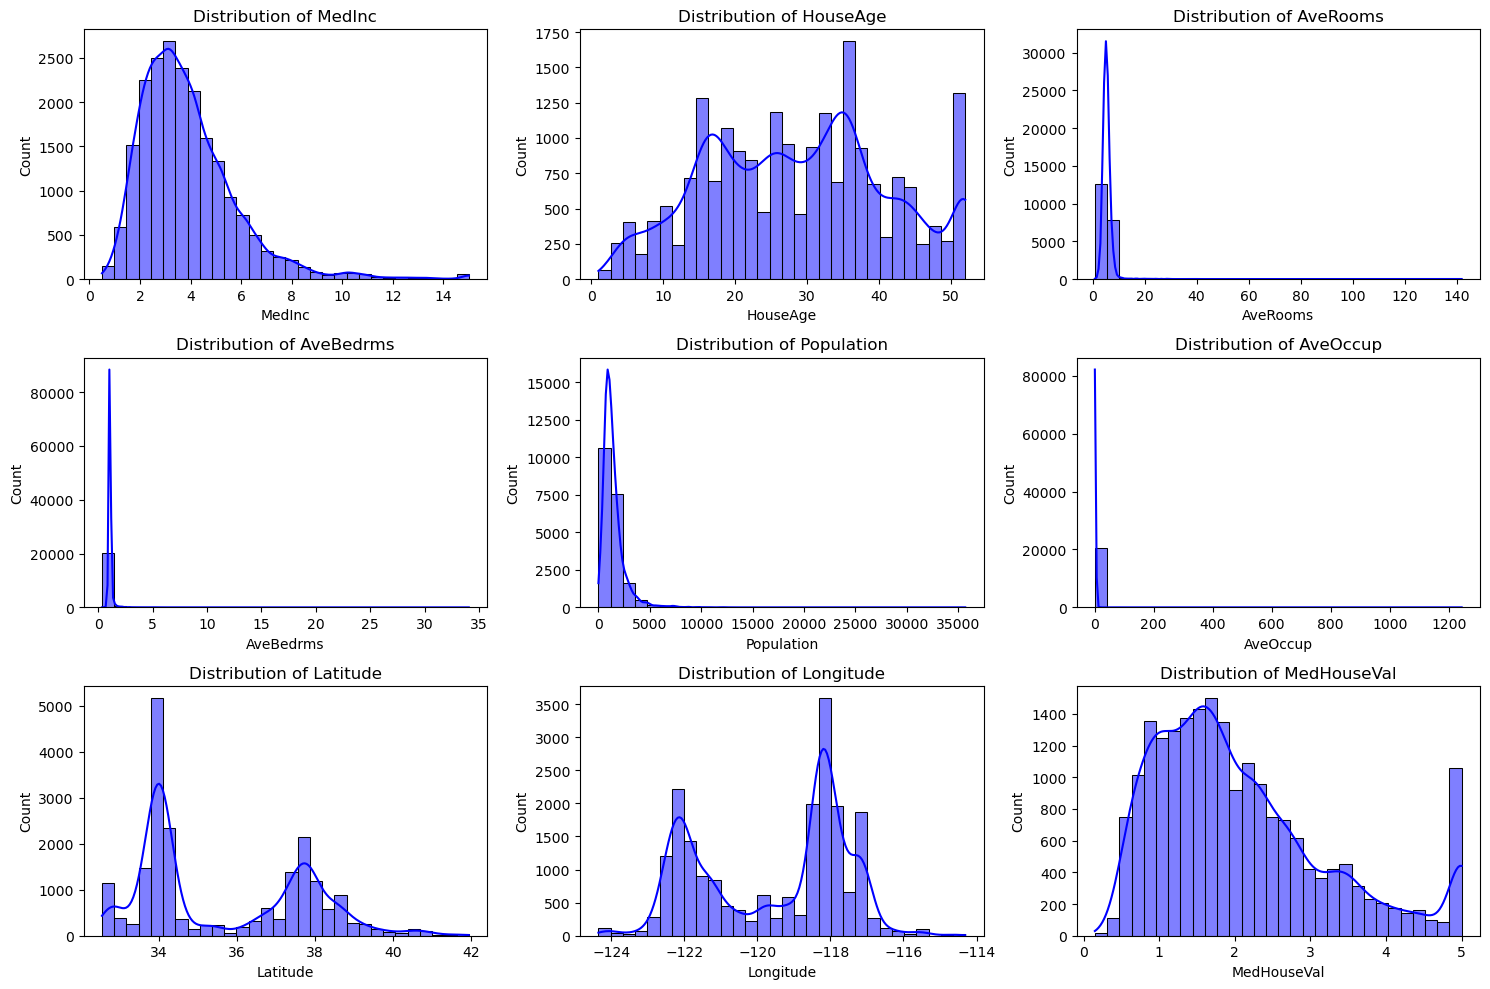

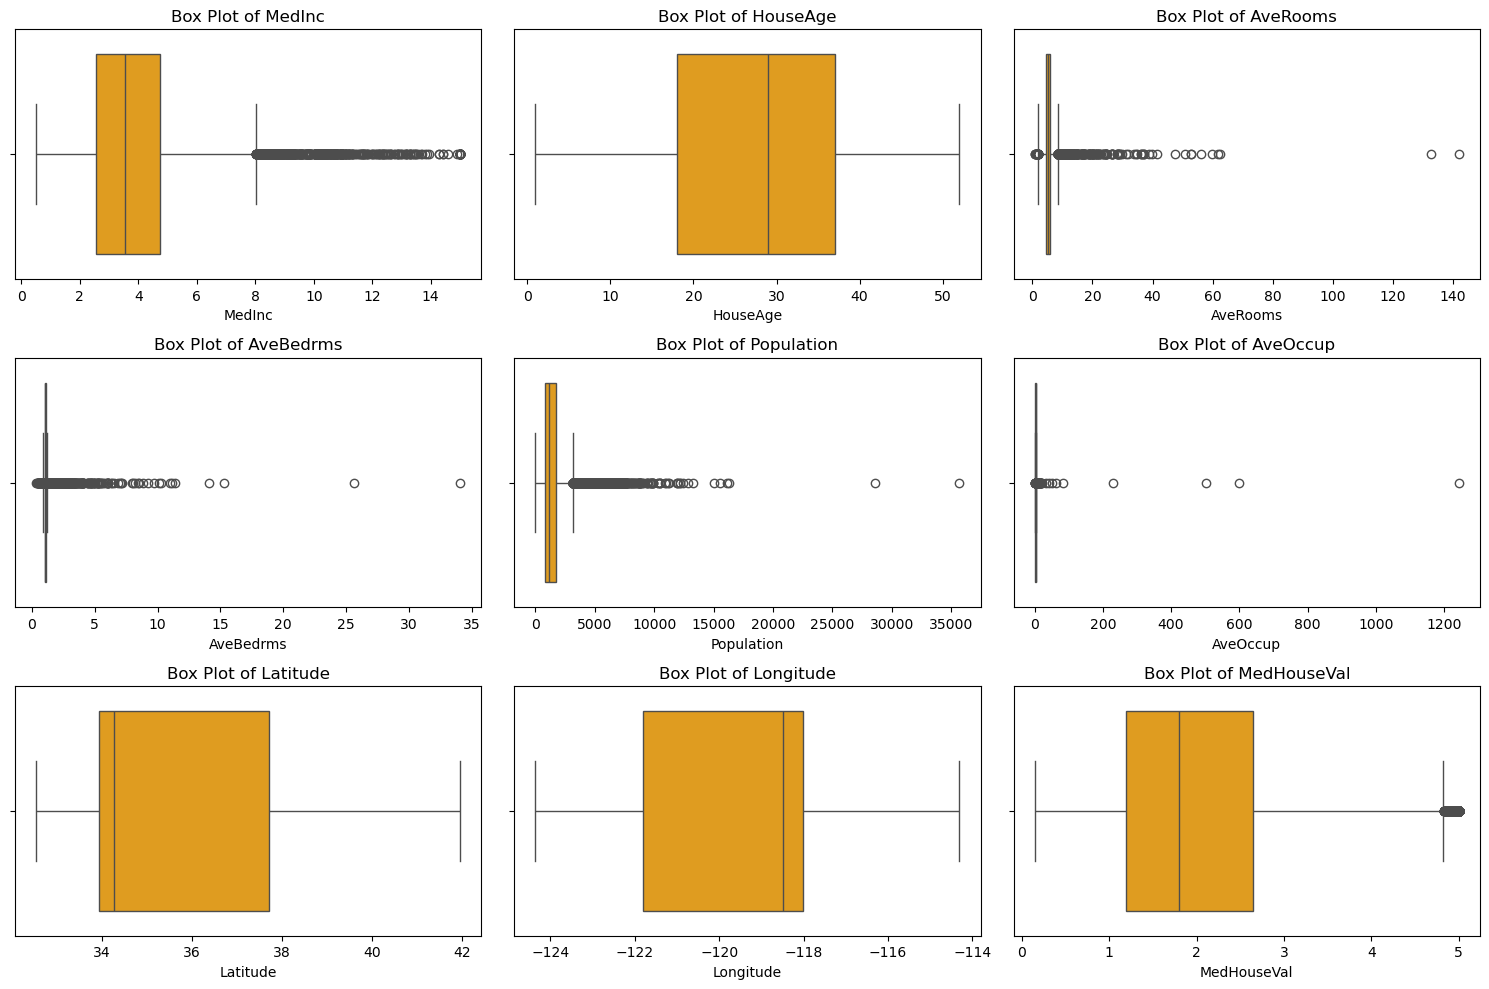

Outliers Detection:
MedInc:681 outliers
HouseAge:0 outliers
AveRooms:511 outliers
AveBedrms:1424 outliers
Population:1196 outliers
AveOccup:711 outliers
Latitude:0 outliers
Longitude:0 outliers
MedHouseVal:1071 outliers

Dataset Summary:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.1200

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

#Load the California Housing Dataset
data=fetch_california_housing(as_frame=True)
housing_df=data.frame

#Create Histograms for Numerical Features
numerical_features=housing_df.select_dtypes(include=[np.number]).columns

#Plot Histograms
plt.figure(figsize=(15,10))
for i,feature in enumerate(numerical_features):
    plt.subplot(3,3,i+1)
    sns.histplot(housing_df[feature],kde=True,bins=30,color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

#Generate Box Plots for numerical features
plt.figure(figsize=(15,10))
for i,feature in enumerate(numerical_features):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=housing_df[feature],color='orange')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

#Identify Outliers using the IQR method
print("Outliers Detection:")
outliers_summary={}
for feature in numerical_features:
    Q1=housing_df[feature].quantile(0.25)
    Q3=housing_df[feature].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=housing_df[(housing_df[feature]<lower_bound)|(housing_df[feature]>upper_bound)]
    outliers_summary[feature]=len(outliers)
    print(f"{feature}:{len(outliers)} outliers")

print("\nDataset Summary:")
print(housing_df)